In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import sqoct_core as sq

In [2]:
t1 = 1.0
mu = 0.0

nk_segment = 160
Nk_DOS = 181

E_DOS = np.linspace(-4.3, 3.1, 1200)

eta_DOS = 0.045

Emin_plot = -4.2
Emax_plot = 3.0

In [3]:
def interpolate_segment(k_start, k_end, n):
    return np.linspace(np.asarray(k_start, dtype=float), np.asarray(k_end, dtype=float), n, endpoint=False)


Gamma = np.array([0.0, 0.0])
X = np.array([np.pi, 0.0])
M = np.array([np.pi, np.pi])


seg_GX = interpolate_segment(Gamma, X, nk_segment)
seg_XM = interpolate_segment(X, M, nk_segment)

# Include final Gamma on final segment
seg_MG = np.linspace(M, Gamma, nk_segment + 1)


k_path = np.vstack([seg_GX, seg_XM, seg_MG])


# Path coordinate
kdist = np.zeros(len(k_path))

for i in range(1, len(k_path)):
    kdist[i] = kdist[i - 1] + np.linalg.norm(k_path[i] - k_path[i - 1])


# High-symmetry locations
ix_G = 0
ix_X = len(seg_GX)
ix_M = len(seg_GX) + len(seg_XM)
ix_G2 = len(k_path) - 1

high_sym_x = [kdist[ix_G], kdist[ix_X], kdist[ix_M], kdist[ix_G2]]

high_sym_labels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]

In [4]:
def calculate_bands(t2):
    bands = np.zeros((len(k_path), 4))

    for ik, (k1, k2) in enumerate(k_path):
        Hk = sq.bloch_hamiltonian(k1=k1, k2=k2, t1=t1, t2=t2, mu=mu)
        bands[ik] = np.linalg.eigvalsh(Hk)

    return bands

In [5]:
t2_values_band = [ 0.20, 0.50, 0.75, 1.00]

band_data = {}

for t2 in t2_values_band:
    print(f"Calculating bands: t2/t1 = {t2:.2f}")
    band_data[float(t2)] = calculate_bands(t2)

Calculating bands: t2/t1 = 0.20
Calculating bands: t2/t1 = 0.50
Calculating bands: t2/t1 = 0.75
Calculating bands: t2/t1 = 1.00


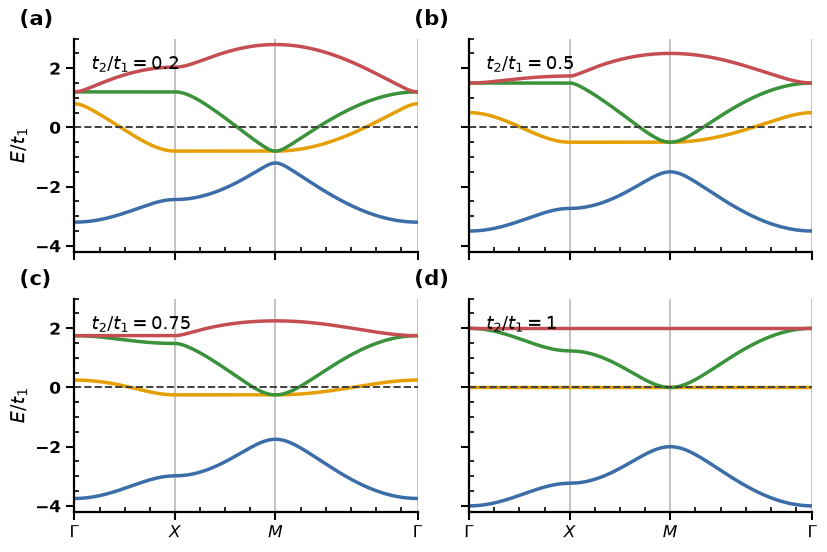

In [6]:
band_colors = [
    "#3B6EA8",   # blue
    "#E69F00",   # orange
    "#3A923A",   # green
    "#C44E52"    # red
]


fig, axes = plt.subplots(
    2, 2, figsize=(8.2, 5.6),
    sharex=True, sharey=True
)

axes = axes.ravel()


for i, t2 in enumerate(t2_values_band):

    ax = axes[i]
    bands = band_data[float(t2)]

    ax.spines["left"].set_linewidth(1.6)
    ax.spines["bottom"].set_linewidth(1.6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both", which="major", direction="out",
        top=False, right=False, length=6, width=1.5, labelsize=12
    )

    ax.tick_params(
        axis="both", which="minor", direction="in",
        top=False, right=False, length=3.5, width=1.2
    )

    for ib in range(4):
        ax.plot(kdist, bands[:, ib], color=band_colors[ib], lw=2.5)

    for xpos in high_sym_x:
        ax.axvline(xpos, color="0.70", lw=1.1, zorder=0)

    ax.axhline(0, color="0.25", ls="--", lw=1.4)

    ax.set_xlim(high_sym_x[0], high_sym_x[-1])
    ax.set_ylim(Emin_plot, Emax_plot)

    ax.set_xticks(high_sym_x)
    ax.set_xticklabels(
        high_sym_labels, fontsize=12, fontweight="bold"
    )

    ax.text(
        0.05, 0.92, rf"$t_2/t_1={t2:g}$",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=13, fontweight="bold"
    )

    ax.minorticks_on()


axes[0].set_ylabel(r"$E/t_1$", fontsize=14, fontweight="bold")
axes[2].set_ylabel(r"$E/t_1$", fontsize=14, fontweight="bold")


for ax in axes:
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")


for ax, label in zip(axes, ["(a)", "(b)", "(c)", "(d)"]):

    ax.text(
        -0.16, 1.04, label,
        transform=ax.transAxes,
        fontsize=15, fontweight="bold",
        va="bottom"
    )


fig.subplots_adjust(
    left=0.095, right=0.995,
    bottom=0.12, top=0.965,
    wspace=0.15, hspace=0.22
)

# fig.savefig(
#     "figures/bands_vary_t2.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()